# 2. Регрессия IC50

In [1]:
# Подключение библиотек

from pathlib import Path
import json
import warnings

from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

random_state = 42
target_columns = ["IC50, mM", "CC50, mM", "SI"]

data_path = Path("/Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/coursework_dataset.csv")
results_dir = Path("/Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results")
figures_dir = results_dir / "figures"
tables_dir = results_dir / "tables"
figures_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

In [2]:
# Загрузка данных

dataset = pd.read_csv(data_path)
dataset = dataset.drop(columns=[column for column in dataset.columns if str(column).startswith("Unnamed")], errors="ignore")
dataset = dataset.apply(pd.to_numeric, errors="coerce")
dataset = dataset.drop_duplicates()
dataset = dataset.dropna(subset=target_columns).reset_index(drop=True)

print("Размер датасета после базовой очистки:", dataset.shape)
print(dataset.head())


Размер датасета после базовой очистки: (969, 213)
     IC50, mM    CC50, mM         SI  MaxAbsEStateIndex  MaxEStateIndex  \
0    6.239374  175.482382  28.125000           5.094096        5.094096   
1    0.771831    5.402819   7.000000           3.961417        3.961417   
2  223.808778  161.142320   0.720000           2.627117        2.627117   
3    1.705624  107.855654  63.235294           5.097360        5.097360   
4  107.131532  139.270991   1.300000           5.150510        5.150510   

   MinAbsEStateIndex  MinEStateIndex       qed        SPS    MolWt  ...  \
0           0.387225        0.387225  0.417362  42.928571  384.652  ...   
1           0.533868        0.533868  0.462473  45.214286  388.684  ...   
2           0.543231        0.543231  0.260923  42.187500  446.808  ...   
3           0.390603        0.390603  0.377846  41.862069  398.679  ...   
4           0.270476        0.270476  0.429038  36.514286  466.713  ...   

   fr_sulfide  fr_sulfonamd  fr_sulfone  fr_term

In [3]:
# Подготовка признаков и целевой переменной

target_column = 'IC50, mM'
task_id = 'regression_ic50'

feature_columns = [column for column in dataset.columns if column not in target_columns]
x = dataset[feature_columns]
y = dataset[target_column].astype(float)

print("Целевая переменная:", target_column)
print("Количество признаков:", x.shape[1])
print(y.describe())


Целевая переменная: IC50, mM
Количество признаков: 210
count     969.000000
mean      220.726223
std       397.172441
min         0.003517
25%        12.515396
50%        45.338355
75%       231.373089
max      4128.529377
Name: IC50, mM, dtype: float64


## Методический вывод

Из матрицы признаков исключены все целевые показатели: IC50, CC50 и SI. Это предотвращает утечку данных, так как значения CC50 и SI связаны с IC50 и не должны использоваться как независимые признаки.

Для IC50 характерна сильная правосторонняя асимметрия и большое число высоких значений. Поэтому в регрессионном конвейере используется логарифмическое преобразование целевой переменной через TransformedTargetRegressor. Такой подход снижает влияние экстремальных значений при обучении и делает сравнение моделей более устойчивым.

In [4]:
# Разбиение данных и описание конвейера обучения

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=random_state,
)


def make_pipeline(model, scale=False):
    # Конвейер выполняет одинаковую предобработку на кросс-валидации и тесте.
    # Медианная импутация обрабатывает пропуски без удаления наблюдений.
    # VarianceThreshold удаляет константные признаки.
    # RobustScaler применяется для моделей, чувствительных к масштабу признаков.
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
    ]
    if scale:
        steps.append(("scaler", RobustScaler()))
    steps.append(("model", model))
    return Pipeline(steps)


base_models = {
    "Ridge": (
        make_pipeline(Ridge(random_state=random_state), scale=True),
        {"regressor__model__alpha": [0.1, 1.0, 10.0, 100.0]},
    ),
    "KNN": (
        make_pipeline(KNeighborsRegressor(), scale=True),
        {"regressor__model__n_neighbors": [5, 15]},
    ),
    "RandomForest": (
        make_pipeline(RandomForestRegressor(random_state=random_state, n_jobs=-1), scale=False),
        {"regressor__model__n_estimators": [120], "regressor__model__max_depth": [None, 12]},
    ),
    "ExtraTrees": (
        make_pipeline(ExtraTreesRegressor(random_state=random_state, n_jobs=-1), scale=False),
        {"regressor__model__n_estimators": [140], "regressor__model__max_depth": [None, 12]},
    ),
    "GradientBoosting": (
        make_pipeline(GradientBoostingRegressor(random_state=random_state), scale=False),
        {"regressor__model__n_estimators": [100, 160], "regressor__model__learning_rate": [0.05, 0.1]},
    ),
}

models = {
    model_name: (
        TransformedTargetRegressor(regressor=model_pipeline, func=np.log1p, inverse_func=np.expm1),
        param_grid,
    )
    for model_name, (model_pipeline, param_grid) in base_models.items()
}


In [5]:
# Обучение моделей и подбор гиперпараметров

cross_validation = KFold(n_splits=3, shuffle=True, random_state=random_state)
metric_rows = []
best_estimator = None
best_rmse = np.inf

for model_name, (model, param_grid) in models.items():
    print("Обучение модели:", model_name)

    search = GridSearchCV(
        model,
        param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cross_validation,
        n_jobs=-1,
    )
    search.fit(x_train, y_train)

    prediction = search.best_estimator_.predict(x_test)
    rmse = root_mean_squared_error(y_test, prediction)
    mae = mean_absolute_error(y_test, prediction)
    r2 = r2_score(y_test, prediction)

    metric_rows.append(
        {
            "model": model_name,
            "cv_rmse": -search.best_score_,
            "test_rmse": rmse,
            "test_mae": mae,
            "test_r2": r2,
            "best_params": json.dumps(search.best_params_, ensure_ascii=False),
        }
    )

    if rmse < best_rmse:
        best_rmse = rmse
        best_estimator = search.best_estimator_

metrics = pd.DataFrame(metric_rows).sort_values("test_rmse").reset_index(drop=True)
metrics_path = tables_dir / f"{task_id}_metrics.csv"
metrics.to_csv(metrics_path, index=False)

print(metrics)
print("Метрики сохранены:", metrics_path)


Обучение модели: Ridge
Обучение модели: KNN
Обучение модели: RandomForest
Обучение модели: ExtraTrees
Обучение модели: GradientBoosting
              model       cv_rmse   test_rmse    test_mae   test_r2  \
0        ExtraTrees  3.671024e+02  397.216861  191.157600  0.280202   
1      RandomForest  3.444090e+02  398.295917  190.966743  0.276286   
2  GradientBoosting  3.400529e+02  409.784159  188.426468  0.233935   
3               KNN  3.598734e+02  433.757807  200.794568  0.141678   
4             Ridge  9.317351e+18  460.386054  208.963318  0.033060   

                                         best_params  
0  {"regressor__model__max_depth": 12, "regressor...  
1  {"regressor__model__max_depth": null, "regress...  
2  {"regressor__model__learning_rate": 0.1, "regr...  
3               {"regressor__model__n_neighbors": 5}  
4                 {"regressor__model__alpha": 100.0}  
Метрики сохранены: /Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_predictio

## Вывод по результатам моделирования

Лучший результат для IC50 показала модель ExtraTrees: RMSE = 397.217, MAE = 191.158, R2 = 0.280. Ансамблевые модели деревьев оказались лучше линейной модели Ridge, что указывает на нелинейный характер связи между молекулярными дескрипторами и активностью соединения.

При этом качество регрессии остается ограниченным: высокие значения IC50 прогнозируются хуже, чем область малых и средних концентраций. Это видно по графику факт-прогноз, где часть точек с большими фактическими значениями заметно отклоняется от диагонали.

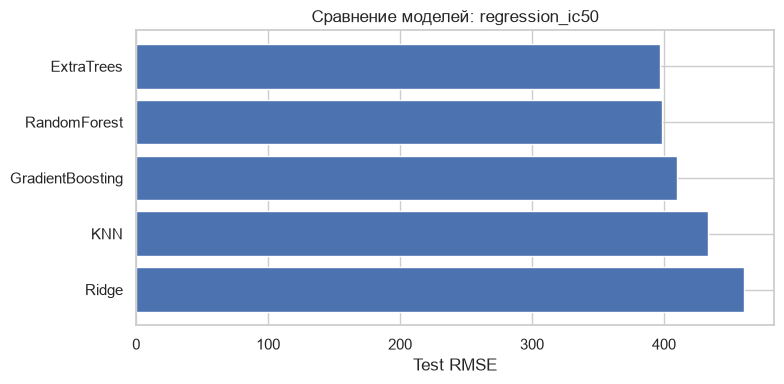

График сохранен: /Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results/figures/regression_ic50_model_comparison.png


In [6]:
# Сравнение моделей по тестовой RMSE

plot_data = metrics.sort_values("test_rmse", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_data["model"], plot_data["test_rmse"])
plt.gca().invert_yaxis()
plt.xlabel("Test RMSE")
plt.title(f"Сравнение моделей: {task_id}")
plt.tight_layout()
comparison_path = figures_dir / f"{task_id}_model_comparison.png"
plt.savefig(comparison_path, dpi=160)
plt.show()

print("График сохранен:", comparison_path)


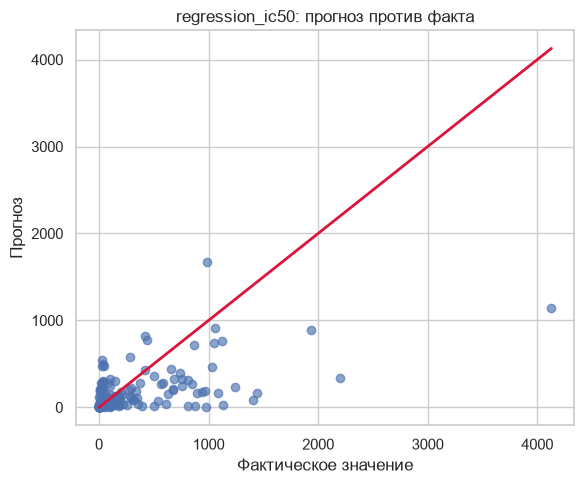

График сохранен: /Users/dmitrijgoncarov/mephi_masters/sem_2/classic_ML/coursework/drug_activity_prediction_variant/notebooks/results/figures/regression_ic50_predicted_vs_actual.png
Лучшая модель: ExtraTrees


In [7]:
# Диагностика лучшей модели

best_prediction = best_estimator.predict(x_test)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, best_prediction, alpha=0.65)
lower_value = min(float(y_test.min()), float(np.min(best_prediction)))
upper_value = max(float(y_test.max()), float(np.max(best_prediction)))
plt.plot([lower_value, upper_value], [lower_value, upper_value], color="crimson", linewidth=2)
plt.xlabel("Фактическое значение")
plt.ylabel("Прогноз")
plt.title(f"{task_id}: прогноз против факта")
plt.tight_layout()
scatter_path = figures_dir / f"{task_id}_predicted_vs_actual.png"
plt.savefig(scatter_path, dpi=160)
plt.show()

print("График сохранен:", scatter_path)
print("Лучшая модель:", metrics.loc[0, "model"])


## Итоговый аналитический вывод

Модель позволяет частично ранжировать соединения по IC50, но для точного прогноза экстремально высоких концентраций качества недостаточно. Для улучшения результата имеет смысл отдельно исследовать выбросы IC50, попробовать более аккуратный отбор признаков и сравнить модели на выборках с разными правилами отсечения хвостов распределения.